# Personal Expense Analysis using Python

### Portfolio Project

**Tools & Libraries**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

**Dataset**
- Personal Expense Dataset (Kaggle)

**Project Type**
- Exploratory Data Analysis (EDA)

**Author**
- Rayusha Maharjan

# 1. Introduction

This project was created to help individuals better understand and manage their personal spending habits by analyzing a publicly available personal expense dataset from Kaggle. It addresses the common problem of unclear expense tracking, where spending across multiple categories can be difficult to interpret and manage effectively. Using Python’s data analysis ecosystem—primarily Pandas for data manipulation, Matplotlib and Seaborn for visualization—the project applies exploratory data analysis (EDA) techniques to clean the dataset, evaluate category‑wise expenses, and uncover trends over time. By transforming raw expense records into meaningful insights, the analysis provides practical recommendations that support informed financial decision‑making and improved budgeting strategies.




# 2. Objectives
- Analyze personal spending patterns.
- Identify the highest spending categories.
- Detect monthly spending trends.
- Understand transaction distribution.
- Generate actionable financial insights.

# 3. Import Libraries

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")  



# 4. Load Dataset

In [2]:
df = pd.read_csv("et.csv")
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


# 5. Data Understanding

In [3]:
print("Shape:", df.shape)
df.info()
print("Columns:", df.columns)

Shape: (277, 11)
<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    str    
 1   Account         277 non-null    str    
 2   Category        277 non-null    str    
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    str    
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    str    
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    str    
 10  Account.1       277 non-null    float64
dtypes: float64(5), str(6)
memory usage: 40.7 KB
Columns: Index(['Date', 'Account', 'Category', 'Subcategory', 'Note', 'INR',
       'Income/Expense', 'Note.1', 'Amount', 'Currency', 'Account.1'],
      dtype='str')


In [4]:
df.describe()

,Subcategory,INR,Note.1,Amount,Account.1
count,0.0,277.000000,0.0,277.000000,277.000000
mean,NaN,410.750903,NaN,406.759134,406.759134
std,NaN,1065.756569,NaN,1065.158318,1065.158318
min,NaN,3.000000,NaN,3.000000,3.000000
25%,NaN,50.000000,NaN,50.000000,50.000000
50%,NaN,128.000000,NaN,125.000000,125.000000
75%,NaN,301.150000,NaN,300.000000,300.000000
max,NaN,10000.000000,NaN,10000.000000,10000.000000


In [5]:
#Missing values per column
df.isnull().sum()



Date                0
Account             0
Category            0
Subcategory       277
Note                4
INR                 0
Income/Expense      0
Note.1            277
Amount              0
Currency            0
Account.1           0
dtype: int64

In [6]:
#Duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()]

Duplicate rows: 0


,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1


In [7]:
df.dtypes

Date                  str
Account               str
Category              str
Subcategory       float64
Note                  str
INR               float64
Income/Expense        str
Note.1            float64
Amount            float64
Currency              str
Account.1         float64
dtype: object

# 6. Data Cleaning

Approach:
Missing Amount: filled using the median Amount for that transaction's Category, since spending scale varies a lot by category (a missing Rent value shouldn't be filled with the same number as a missing Coffee value).
Missing Category: filled with "Uncategorized" rather than dropped, so we don't lose real spending data — and the size of this bucket becomes its own insight.



In [8]:
# Fill missing SUbcategory first (Amount fill below depends on Subcategory groups)
df['Subcategory'] = df['Subcategory'].fillna('Uncategorized')

# Fill missing Note using the fillna
df['Note'] = df['Note'].fillna('No Note')

# Fill missing Note.1 using the fillna
df['Note.1'] = df['Note.1'].fillna('No Note')

# Confirm no missing values remain
df.isnull().sum()

Date              0
Account           0
Category          0
Subcategory       0
Note              0
INR               0
Income/Expense    0
Note.1            0
Amount            0
Currency          0
Account.1         0
dtype: int64

In [9]:
#Correcting data types
df['Date'] = pd.to_datetime(df['Date'])
df['Account'] = df['Account'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Subcategory'] = df['Subcategory'].astype('category')
df['Income/Expense'] = df['Income/Expense'].astype('category')
df['Note.1'] = df['Note.1'].astype('str')
df['Currency'] = df['Currency'].astype('category')
df.dtypes

Date              datetime64[us]
Account                 category
Category                category
Subcategory             category
Note                         str
INR                      float64
Income/Expense          category
Note.1                       str
Amount                   float64
Currency                category
Account.1                float64
dtype: object

In [7]:
#Save the cleaned dataset
df.to_csv("cleaned_expense.csv", index=False)
print("Saved cleaned_expense.csv with shape:", df.shape)

Saved cleaned_expense.csv with shape: (277, 11)


# 7. Exploratory Data Analysis

In [10]:
# Total expenses
total_expense = df['Amount'].sum()
print(f"Total Expenses: {total_expense:,.2f}")

# avg,min,max
print(f"Average Expense: {df['Amount'].mean():,.2f}")
print(f"Maximum Expense: {df['Amount'].max():,.2f}")
print(f"Minimum Expense: {df['Amount'].min():,.2f}")


Total Expenses: 112,672.28
Average Expense: 406.76
Maximum Expense: 10,000.00
Minimum Expense: 3.00


In [11]:
# Highest spending category
category_totals = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
print("\nTotal Spending by category (highest first):")
print(category_totals)
print(f"\nHighest spending category: {category_totals.idxmax()} ({category_totals.max():,.2f})")


Total Spending by category (highest first):
Category
Other               37868.00
Food                23396.76
Allowance           14000.00
Household           12188.00
Transportation       9203.80
Salary               8000.00
Apparel              3388.00
Social Life          2513.72
Education            1400.00
Self-development      400.00
Beauty                196.00
Gift                  115.00
Petty cash              3.00
Name: Amount, dtype: float64

Highest spending category: Other (37,868.00)


In [12]:
# Count of transactions by category
category_counts = df['Category'].value_counts()
print("\nTransaction count by category:")
print(category_counts)


Transaction count by category:
Category
Food                156
Other                60
Transportation       31
Apparel               7
Allowance             6
Household             6
Social Life           5
Beauty                1
Education             1
Gift                  1
Petty cash            1
Salary                1
Self-development      1
Name: count, dtype: int64


### Initial Analysis of Spending Categories
Even though the other category has highest spending, but the food category is the category with most transaction

# 8. Data Visualizations 

## 8.1 Histogram of Expense Amounts

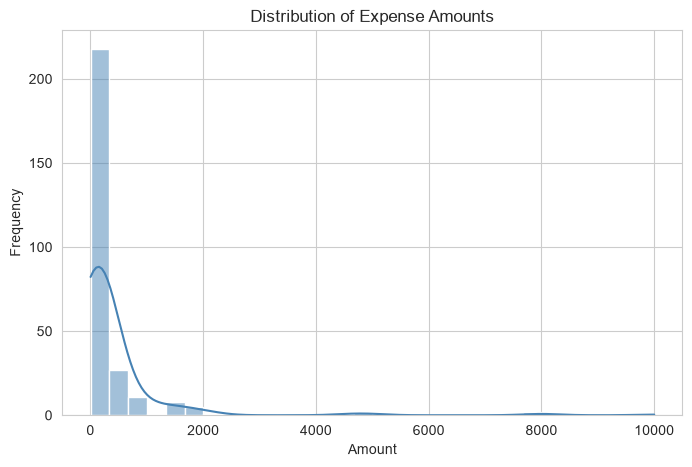

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Expense Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.show()

### Observation
- Most expense amounts are concentrated at lower values.
- A few large transactions create a long right tail.

### Interpretation
The expense distribution is positively skewed, indicating that everyday spending consists mainly of small purchases, while occasional large expenses contribute significantly to the total expenditure.

## 8.2 Boxplot of Expense Amounts

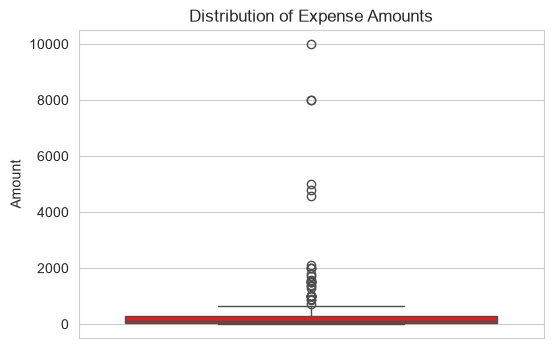

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Amount"], color="red")   # only expense amounts
plt.title("Distribution of Expense Amounts")
plt.ylabel("Amount")
plt.show()



### Observation
Most expense values fall within a relatively narrow range.
Several points appear above the upper whisker, indicating potential outliers.
The median expense is closer to the lower quartile.
### Interpretation
- The box (IQR) shows the middle 50% of expenses, clustered at low amounts.
- Outliers around 2k, 4k, 8k, and 10k indicate rare but significant large expenses.
- Typical spending is small and stable, while a few extreme values stretch the overall scale.


In [15]:
#Analyzig the spending patterns over time by creating new following columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day_name()
df["Weekday"] = df["Date"].dt.dayofweek
df.head()


,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Year,Month,Day,Weekday
0,2022-03-02 10:11:00,CUB - online payment,Food,Uncategorized,Brownie,50.0,Expense,No Note,50.0,INR,50.0,2022,March,Wednesday,2
1,2022-03-02 10:11:00,CUB - online payment,Other,Uncategorized,To lended people,300.0,Expense,No Note,300.0,INR,300.0,2022,March,Wednesday,2
2,2022-03-01 19:50:00,CUB - online payment,Food,Uncategorized,Dinner,78.0,Expense,No Note,78.0,INR,78.0,2022,March,Tuesday,1
3,2022-03-01 18:56:00,CUB - online payment,Transportation,Uncategorized,Metro,30.0,Expense,No Note,30.0,INR,30.0,2022,March,Tuesday,1
4,2022-03-01 18:22:00,CUB - online payment,Food,Uncategorized,Snacks,67.0,Expense,No Note,67.0,INR,67.0,2022,March,Tuesday,1


## 8.3 Bar Chart of Monthly Expense

In [16]:
#Total spending by months
df.groupby("Month")["Amount"].sum()



Month
December    27538.72
February    36064.65
January     40320.51
March        1125.00
November     7623.40
Name: Amount, dtype: float64

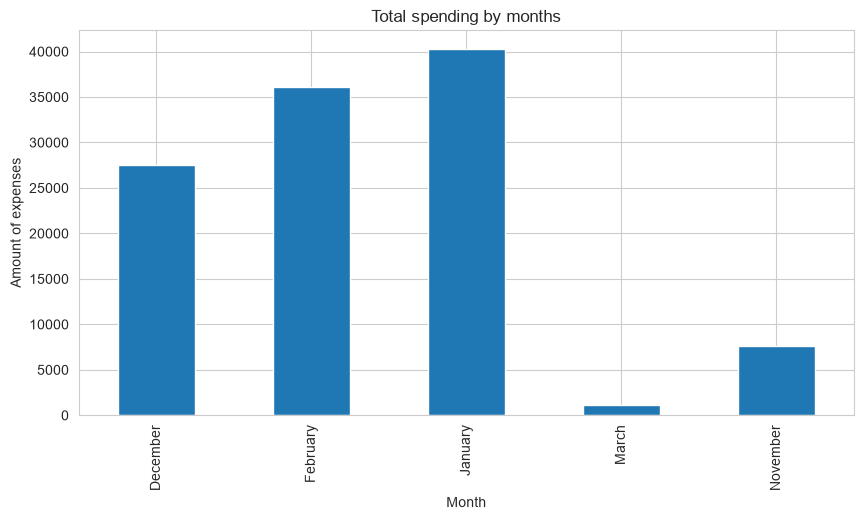

In [17]:
#Visualizing Total spending by months
df.groupby("Month")["Amount"].sum().plot(kind='bar', figsize=(10,5))
plt.title("Total spending by months")
plt.xlabel("Month")
plt.ylabel("Amount of expenses")
plt.show()



### Observation
- Monthly expenses vary throughout the year.
- Some months record noticeably higher spending than    others.
- The spending pattern is not consistent across all months.
### Interpretation
The variation in monthly expenses suggests that spending habits change over time due to seasonal events, personal needs, or irregular purchases.Identifying months with higher expenses can help in creating more effective monthly budgets and improving financial planning.

In [ ]:
#Number of transactions per month
df.groupby("Month").size()

Month
December    89
February    54
January     92
March        7
November    35
dtype: int64

- We can observe that, the number of transaction is directly propotional to the spending per month

In [26]:
#spending by day of the week
df.groupby("Day")["Amount"].sum().sort_values(ascending=True)


Day
Monday        6248.95
Wednesday     6634.75
Friday        6910.00
Thursday      9570.51
Tuesday      17344.65
Sunday       31542.40
Saturday     34421.02
Name: Amount, dtype: float64

- Peak spending on weekends, higher spedings on thurs & tues, mid-range spending on wed & fri and lowest spending on the start day of week

## 8.4 Category-wise Expense Bar Chart

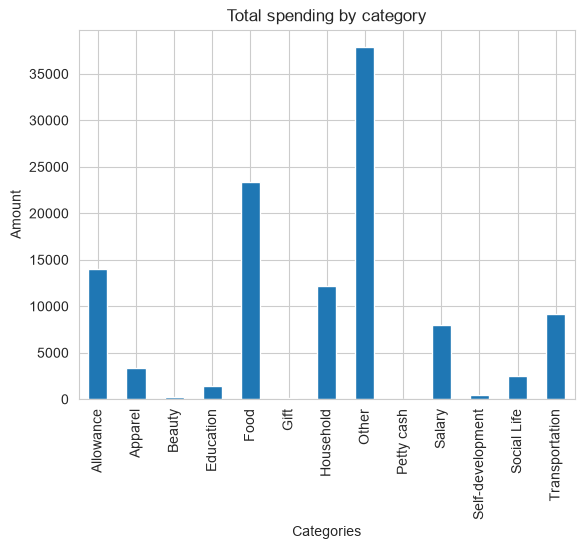

In [18]:
# Total spending by category
df.groupby("Category")["Amount"].sum().plot(kind ='bar')
plt.title("Total spending by category")
plt.xlabel("Categories")
plt.ylabel("Amount")
plt.show()

### Observation
- Spending is uneven across categories.
- "Other" dominates with the highest expense (~38k), followed by "Food" (~23k) and "Allowance" (~14k).
- Categories like Beauty, Gift, and Self-development show very low spending.
- This indicates resources are concentrated in a few major areas, while most categories consume relatively little.

### Interpretation
Category-wise analysis highlights where most of the money is spent. High-spending categories should be monitored regularly, while the large "Other" category suggests that transactions could be classified into more specific categories for better financial analysis and decision-making.


## 8.5 Expense Distribution (Pie Chart)

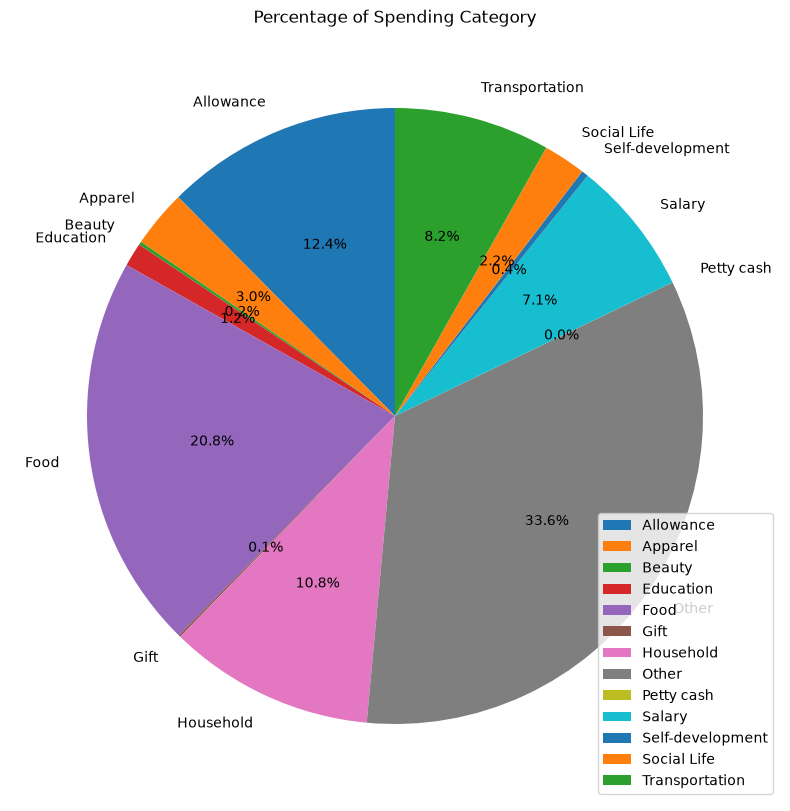

In [ ]:
#Percentage of spending categroy
df.groupby("Category")["Amount"].sum().plot(kind = 'pie',  
                                            autopct='%1.1f%%',
                                            startangle = 90,
                                            legend = True,       #legend : The pie chart shows only percentages (or values) on the slices.
                                            figsize = (10,10))
plt.title("Percentage of Spending Category")
plt.ylabel("")  #remove default y-label
plt.show()

### Observation
The pie chart shows the proportion of expenses across different categories.
One or two categories occupy the largest percentage of the total spending.
Several categories contribute only a small percentage.

### Interpretation
The pie chart provides a clear overview of spending distribution. Categories with the largest proportions have the greatest impact on the overall budget and should be prioritized when planning savings or reducing expenses. Smaller categories have a relatively minor influence on total expenditure.


# 9. Key Insights & Findings

## Spending Patterns
- **Total expenses** are dominated by a few large transactions, with most individual expenses being small amounts
- **January** records the highest spending, while **March** has the lowest, with spending directly correlated to transaction frequency
- **Weekends and mid-week** (Thursday, Tuesday) show peak spending, while **Mondays** have the lowest transaction activity

## Category Analysis
- **"Other" category** is the largest expense driver and requires close monitoring to identify and reduce unclassified spending
- **Food and Allowance** categories consist of fewer but larger transactions that significantly impact the budget
- **Small transaction categories** (petty cash, self-development, beauty, gifts) are frequent but individually minor—they accumulate unnoticed



# 10. Recommendations for Budget Management
1. **Prioritize "Other" category** - Implement alerts and review unclassified transactions regularly to prevent budget leakage
2. **Consolidate small transactions** - Set spending caps for small frequent categories to prevent accumulation
3. **Track large transactions** - Focus budgeting controls on Food and Allowance categories as they drive overall spending
4. **Optimize timing** - Review mid-week and weekend spending patterns to identify discretionary opportunities
5. **Future planning** - Consider redirecting surplus funds toward savings, investments, and insurance after controlling discretionary spending

# 11. Future Scope

This project can be improved by:

- Building an interactive Streamlit dashboard
- Adding budget prediction using Machine Learning
- Creating expense alerts
- Integrating with SQL database
- Connecting to real-time expense tracking

# 12. Conclusion

This project analyzed a Kaggle personal expense dataset to uncover spending behavior using Python, Pandas, Matplotlib, and Seaborn. The workflow included data cleaning, exploratory data analysis, and visualization of category‑wise and time‑based spending trends.

The findings reveal that while most transactions are relatively small, a few high‑value expenses significantly influence overall totals. The **Other** category contributes the largest share of spending, while **Food** records the highest number of transactions. Monthly and weekly analyses highlight periods of increased expenditure, suggesting opportunities for improved financial planning.

From this analysis, it was learned that spending is concentrated in a few categories, with occasional large transactions stretching the overall scale. Practical recommendations include better categorization of expenses, consistent tracking, and setting limits on high‑frequency categories such as Food. 


